In [1]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
base_dir = './dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))

Train count = 1067
Val count = 234
Test count = 267


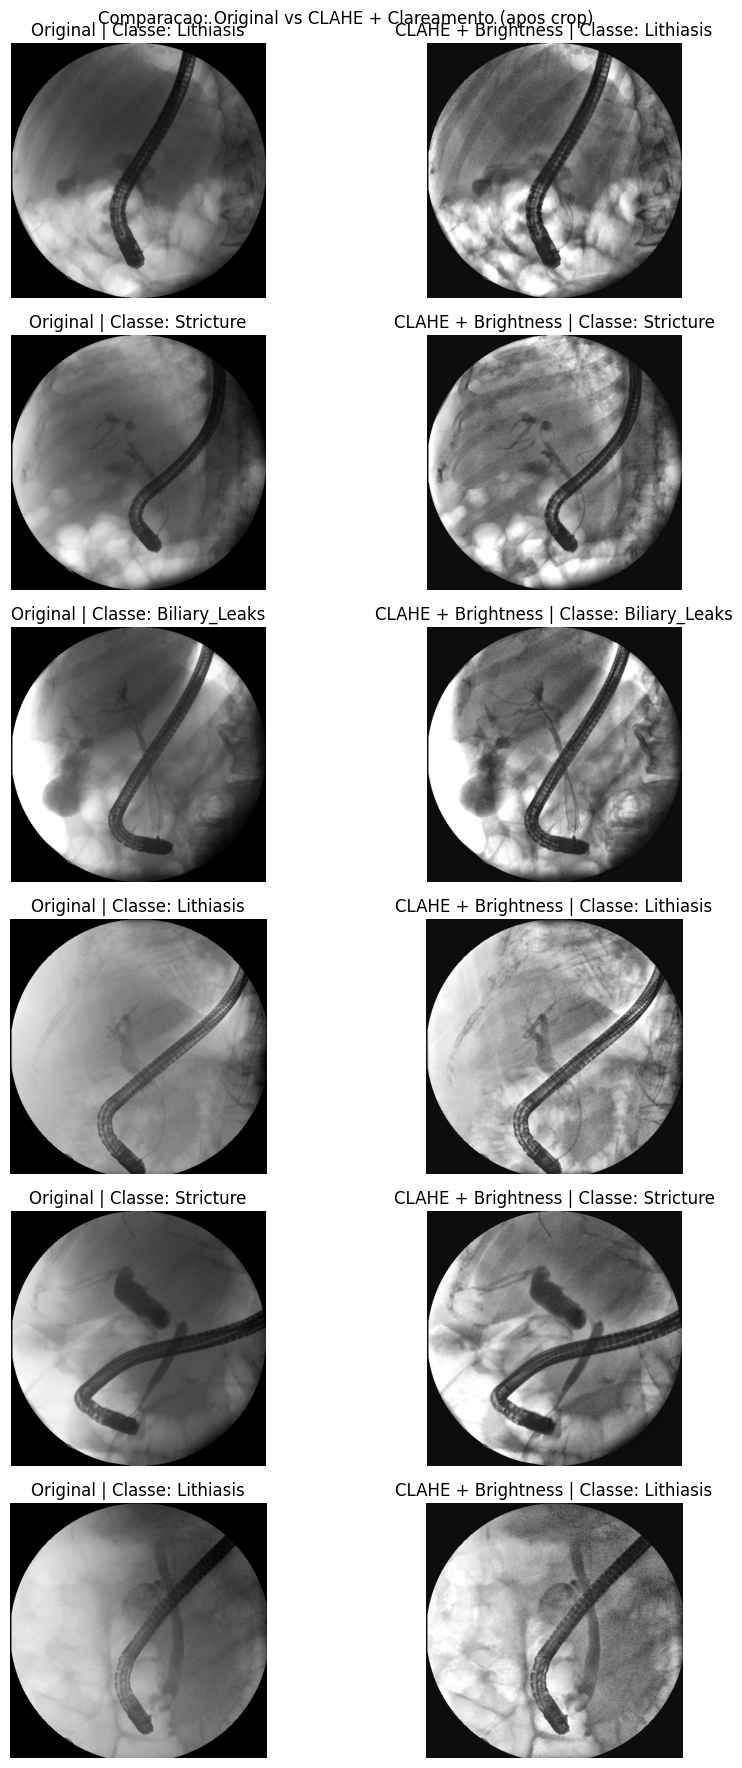

In [3]:
num_examples = 6  # Quantas imagens mostrar
indices = np.random.choice(len(data['train']['images']), num_examples, replace=False)

# Ajuste estes valores para deixar a imagem mais clara
CLAHE_CLIP_LIMIT = 3.0
CLAHE_TILE_GRID_SIZE = (12, 12)
# F1 Score: 0.6560
# BRIGHTNESS_ALPHA = 1.2  # contraste leve (>1 aumenta contraste)
# BRIGHTNESS_BETA = 20     # brilho aditivo (>0 clareia)
# F1 Score: 0.6898
# BRIGHTNESS_ALPHA = 1.4  # contraste leve (>1 aumenta contraste)
# BRIGHTNESS_BETA = 15     # brilho aditivo (>0 clareia)
BRIGHTNESS_ALPHA = 1.1  # contraste leve (>1 aumenta contraste)
BRIGHTNESS_BETA = 5     # brilho aditivo (>0 clareia)

def crop_black_borders(arr, threshold=5):
    if arr.ndim == 3:
        mask = arr.max(axis=2) > threshold
    else:
        mask = arr > threshold
    coords = np.argwhere(mask)
    if coords.size == 0:
        return arr
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return arr[y0:y1, x0:x1]

def apply_clahe(arr, clip_limit=2.0, tile_grid_size=(8, 8), alpha=1.0, beta=0):
    if arr.ndim == 3:
        # CLAHE na luminancia e ajuste de brilho posterior
        lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        l_eq = clahe.apply(l)
        l_eq = cv2.convertScaleAbs(l_eq, alpha=alpha, beta=beta)
        return cv2.cvtColor(cv2.merge((l_eq, a, b)), cv2.COLOR_LAB2RGB)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    arr_eq = clahe.apply(arr)
    return cv2.convertScaleAbs(arr_eq, alpha=alpha, beta=beta)

fig, axes = plt.subplots(num_examples, 2, figsize=(10, 3 * num_examples))
for i, idx in enumerate(indices):
    img_path = data['train']['images'][idx]
    label = class_names[data['train']['labels'][idx]]
    img = Image.open(img_path)
    arr = np.array(img)
    arr_cropped = crop_black_borders(arr)
    arr_clahe = apply_clahe(
        arr_cropped,
        clip_limit=CLAHE_CLIP_LIMIT,
        tile_grid_size=CLAHE_TILE_GRID_SIZE,
        alpha=BRIGHTNESS_ALPHA,
        beta=BRIGHTNESS_BETA,
    )

    axes[i, 0].imshow(arr_cropped, cmap='gray' if arr_cropped.ndim == 2 else None, vmin=0, vmax=255)
    axes[i, 0].set_title(f"Original | Classe: {label}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(arr_clahe, cmap='gray' if arr_clahe.ndim == 2 else None, vmin=0, vmax=255)
    axes[i, 1].set_title(f"CLAHE + Brightness | Classe: {label}")
    axes[i, 1].axis('off')

plt.suptitle('Comparacao: Original vs CLAHE + Clareamento (apos crop)')
plt.tight_layout()
plt.show()

In [4]:
output_base_dir = './dataset_clahe_v2'
Path(output_base_dir).mkdir(parents=True, exist_ok=True)

def save_clahe_dataset(
    input_base_dir,
    output_base_dir,
    phases,
    clip_limit=2.5,
    tile_grid_size=(8, 8),
    alpha=1.08,
    beta=18,
):
    total = 0
    for phase in phases:
        phase_in = Path(input_base_dir) / phase
        phase_out = Path(output_base_dir) / phase
        phase_out.mkdir(parents=True, exist_ok=True)

        for class_name in sorted([p.name for p in phase_in.iterdir() if p.is_dir()]):
            class_in = phase_in / class_name
            class_out = phase_out / class_name
            class_out.mkdir(parents=True, exist_ok=True)

            for img_name in os.listdir(class_in):
                if not img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                    continue

                in_path = class_in / img_name
                out_path = class_out / img_name

                arr = np.array(Image.open(in_path))
                arr_cropped = crop_black_borders(arr)
                arr_clahe = apply_clahe(
                    arr_cropped,
                    clip_limit=clip_limit,
                    tile_grid_size=tile_grid_size,
                    alpha=alpha,
                    beta=beta,
                )

                Image.fromarray(arr_clahe).save(out_path)
                total += 1

    return total

total_processed = save_clahe_dataset(
    input_base_dir=base_dir,
    output_base_dir=output_base_dir,
    phases=phases,
    clip_limit=CLAHE_CLIP_LIMIT,
    tile_grid_size=CLAHE_TILE_GRID_SIZE,
    alpha=BRIGHTNESS_ALPHA,
    beta=BRIGHTNESS_BETA,
)

print(f'Imagens processadas com CLAHE: {total_processed}')
print(f'Dataset salvo em: {output_base_dir}')
print(f'Parametros: clip_limit={CLAHE_CLIP_LIMIT}, tile={CLAHE_TILE_GRID_SIZE}, alpha={BRIGHTNESS_ALPHA}, beta={BRIGHTNESS_BETA}')

Imagens processadas com CLAHE: 1568
Dataset salvo em: ./dataset_clahe_v2
Parametros: clip_limit=3.0, tile=(12, 12), alpha=1.1, beta=5
